# Вариант №1.

# Базовая настройка

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import math as m
import statsmodels.api as sm
from IPython.display import display, Markdown

In [5]:
variant = 1

def mprint(*strings):  
    for s in strings:
        display(Markdown(s))


def dataframe_to_markdown(df):
    if df.index.name is None:
        first_cell = "Index"
    elif df.columns.name is None:
        first_cell = df.index.name
    else:
        first_cell = df.index.name + "\\" + df.columns.name
    markdown_table = "| " + first_cell + " | " + " | ".join(df.columns) + " |\n"
    markdown_table += "|---" * (len(df.columns) + 1) + "|\n"  # Учитываем индекс

    for index, row in df.iterrows():
        row_values = [str(round(val, 2) if type(val) != str else val) for val in row]
        markdown_table += f"| {index} | " + " | ".join(row_values) + " |\n"

    return markdown_table


# можно выводить latex в надписях matplotlib
plt.rc("text", usetex=True)
plt.rc(
    "text.latex",
    preamble=r"""
\usepackage[english, russian]{babel}
\usepackage[utf8]{inputenc}
""",
)
plt.style.use("seaborn-v0_8")

path_to_vars = "bdz_vars.xls"
path_to_data = "bdz_data.xls"

In [6]:
datas = pd.read_excel(path_to_vars, index_col=0).loc[variant]

variant_dict = dict()
for tasks in datas.index:
    for task in tasks.split(", "):
        variant_dict[task] = (
            datas[tasks]
            .replace("А", "A")
            .replace("В", "B")
            .replace("С", "C")
            .split(" ")
        )

In [7]:
dfs = pd.read_excel(path_to_data, sheet_name=None)
sheet_dict = dict()
for value in list(dfs.keys())[1:]:
    key = value[0]
    sheet_dict[key] = value

def data(task):
    X = []
    for data in variant_dict[task]:
        sheet = data[0]
        column = data
        df = dfs[sheet_dict[sheet]][column]
        X.append(df)
    return X

def verdict(alpha, p_value):
    if alpha > p_value:
        return "$H_0$ отклоняется"
    else:
        return "$H_0$ принимается"

# 1. Описательные статистики

## 1.1 Выборочные характеристики


In [8]:
columns = data("1.1")

for i, X in enumerate(columns, start=1):
    mean_ = X.mean()
    D = X.var(ddof=0)
    d = X.std(ddof=0)
    g = stats.skew(X, bias=True)
    e = stats.kurtosis(X, bias=True)
    output = f"$\\mathbf{{X_{i}}}:$ \
        $\\overline x_{i} =$ {mean_:.2f}; \
        $D^*_{{X_{i}}} =$ {D:.2f}; \
        $\\sigma^*_{{X_{i}}} =$ {d:.2f}; \
        $\\gamma^*_{{X_{i}}} =$ {g:.2f}; \
        $\\varepsilon^*_{{X_{i}}} =$ {e:.2f} \
        "
    
    mprint(output)

$\mathbf{X_1}:$         $\overline x_1 =$ 526.48;         $D^*_{X_1} =$ 13855.93;         $\sigma^*_{X_1} =$ 117.71;         $\gamma^*_{X_1} =$ 0.68;         $\varepsilon^*_{X_1} =$ 0.53         

$\mathbf{X_2}:$         $\overline x_2 =$ 420.04;         $D^*_{X_2} =$ 4953.14;         $\sigma^*_{X_2} =$ 70.38;         $\gamma^*_{X_2} =$ 0.35;         $\varepsilon^*_{X_2} =$ 0.18         

$\mathbf{X_3}:$         $\overline x_3 =$ 355.09;         $D^*_{X_3} =$ 2901.58;         $\sigma^*_{X_3} =$ 53.87;         $\gamma^*_{X_3} =$ 0.45;         $\varepsilon^*_{X_3} =$ 0.43         

## 1.2 Группировка и гистограммы частот

In [9]:
X = data("1.2")[0]
n = len(X)

X = pd.DataFrame(X.values, columns=["value"])
maximum = max(X["value"])
minimum = min(X["value"])
k = round(1 + 3.322 * m.log10(n))

mprint(f"$\\mathbf{{X}}: \\max = {maximum}, \\min = {minimum}, n = {n}, k = {k}$")

$\mathbf{X}: \max = 1009, \min = 270, n = 1073, k = 11$

In [10]:
X["group"] = pd.cut(X["value"], bins=k)

delta_min = np.min(
    [interval.right - interval.left for interval in X["group"].cat.categories]
)
delta_max = np.max(
    [interval.right - interval.left for interval in X["group"].cat.categories]
)

mprint(f"Ширина интервалов: от {delta_min:.2f} до {delta_max:.2f}")

Ширина интервалов: от 67.18 до 67.92

In [11]:
groups = pd.DataFrame(index=pd.Index(range(1, k + 1), name="Номер интервала"))
groups["low edge"] = [interval.left for interval in X["group"].cat.categories]
groups["high edge"] = [interval.right for interval in X["group"].cat.categories]
groups["frequency"] = X["group"].value_counts().sort_index().values
groups["relative frequency"] = groups["frequency"] / n
groups["cumulative frequency"] = groups["frequency"].cumsum()
groups["cumulative relative frequency"] = groups["cumulative frequency"] / n

print(dataframe_to_markdown(groups))

| Номер интервала | low edge | high edge | frequency | relative frequency | cumulative frequency | cumulative relative frequency |
|---|---|---|---|---|---|---|
| 1 | 269.26 | 337.18 | 28.0 | 0.03 | 28.0 | 0.03 |
| 2 | 337.18 | 404.36 | 118.0 | 0.11 | 146.0 | 0.14 |
| 3 | 404.36 | 471.55 | 227.0 | 0.21 | 373.0 | 0.35 |
| 4 | 471.55 | 538.73 | 277.0 | 0.26 | 650.0 | 0.61 |
| 5 | 538.73 | 605.91 | 171.0 | 0.16 | 821.0 | 0.77 |
| 6 | 605.91 | 673.09 | 123.0 | 0.11 | 944.0 | 0.88 |
| 7 | 673.09 | 740.27 | 80.0 | 0.07 | 1024.0 | 0.95 |
| 8 | 740.27 | 807.46 | 31.0 | 0.03 | 1055.0 | 0.98 |
| 9 | 807.46 | 874.64 | 7.0 | 0.01 | 1062.0 | 0.99 |
| 10 | 874.64 | 941.82 | 7.0 | 0.01 | 1069.0 | 1.0 |
| 11 | 941.82 | 1009.0 | 4.0 | 0.0 | 1073.0 | 1.0 |



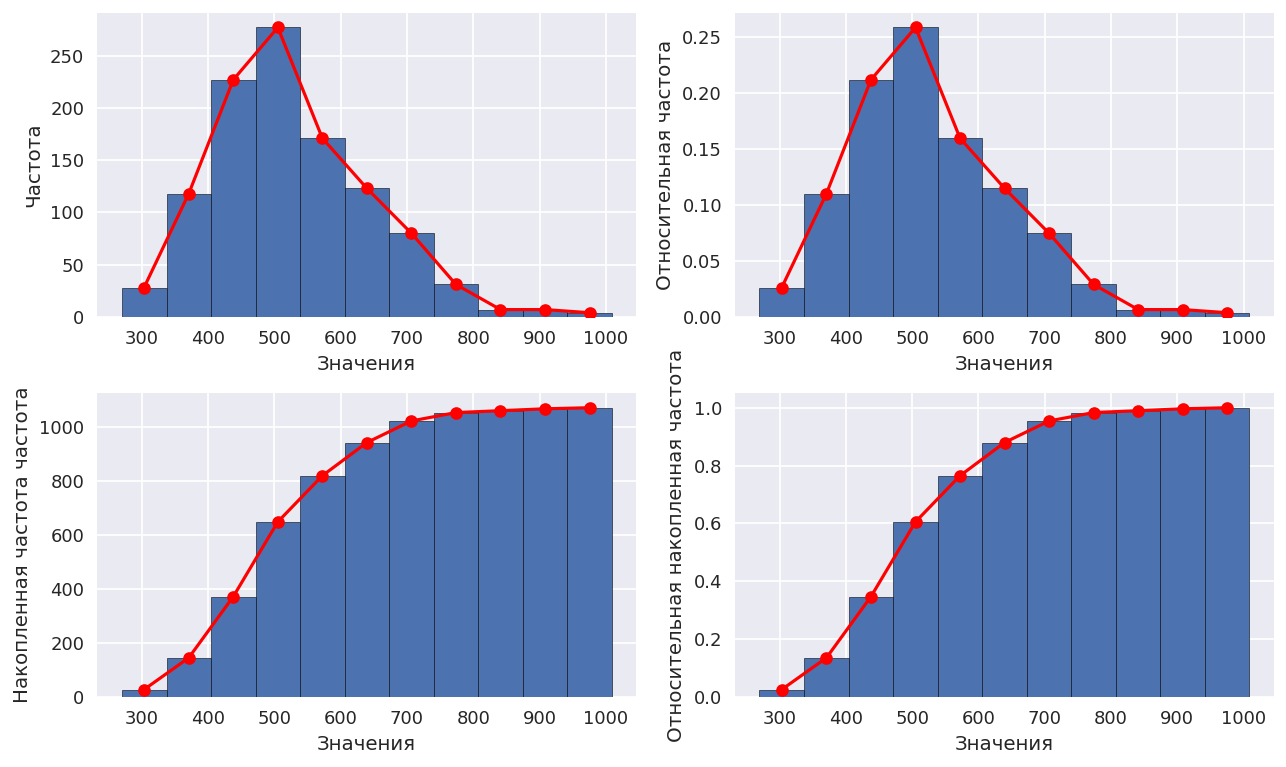

In [12]:
bin_centers = (groups["low edge"] + groups["high edge"]) / 2
width = groups["high edge"] - groups["low edge"]

mpl.rcParams.update({
    "text.usetex": False,
    "axes.unicode_minus": False,
    "font.family": "DejaVu Sans",
    "figure.dpi": 130,
})

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].bar(
    bin_centers,
    groups["frequency"],
    width=width,
    edgecolor="black",
)
axes[0, 0].plot(bin_centers, groups["frequency"], marker="o", color="r")
axes[0, 0].set_xlabel("Значения")
axes[0, 0].set_ylabel("Частота")

axes[0, 1].bar(
    bin_centers,
    groups["relative frequency"],
    width=width,
    edgecolor="black",
)
axes[0, 1].plot(bin_centers, groups["relative frequency"], marker="o", color="r")
axes[0, 1].set_xlabel("Значения")
axes[0, 1].set_ylabel("Относительная частота")


axes[1, 0].bar(
    bin_centers,
    groups["cumulative frequency"],
    width=width,
    edgecolor="black",
)
axes[1, 0].plot(bin_centers, groups["cumulative frequency"], marker="o", color="r")
axes[1, 0].set_xlabel("Значения")
axes[1, 0].set_ylabel("Накопленная частота частота")


axes[1, 1].bar(
    bin_centers,
    groups["cumulative relative frequency"],
    width=width,
    edgecolor="black",
)
axes[1, 1].plot(
    bin_centers, groups["cumulative relative frequency"], marker="o", color="r"
)
axes[1, 1].set_xlabel("Значения")
axes[1, 1].set_ylabel("Относительная накопленная частота")

plt.tight_layout()
plt.show()

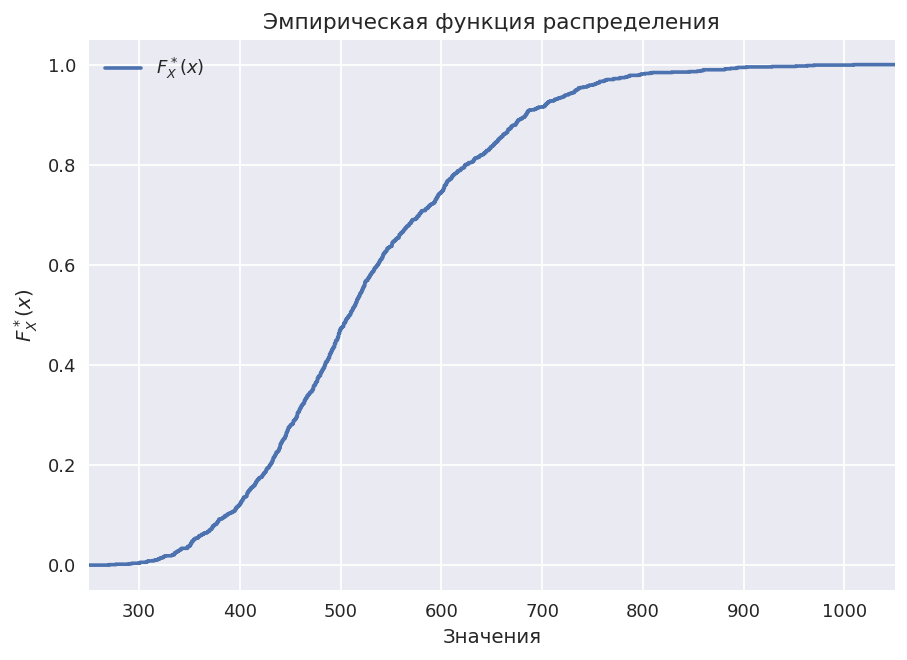

In [13]:
X_sorted = np.sort(X["value"])
X_sorted = np.concatenate(([-10000], X_sorted, [10000]))
F = np.arange(1, n + 1) / n
F = np.concatenate(([0], F, [1]))
plt.step(X_sorted, F, where="post", label=r"$F_X^*(x)$", linewidth=2)
plt.xlim(250, 1050)
plt.xlabel("Значения")
plt.ylabel("$F^*_X(x)$")
plt.legend()
plt.title("Эмпирическая функция распределения")
plt.show()

# 2. Интервальные оценки

## 2.1 Доверительные интервалы для математического ожидания


In [14]:
X = data("2.1")[0]
n = len(X)

intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)

alphas = [0.01, 0.05, 0.1]
std_err = stats.sem(X)
for alpha in alphas:
    intervals[f"alpha = {alpha}"] = stats.t.interval(
        1 - alpha, df=n - 1, loc=X.mean(), scale=std_err
    )
    
print(dataframe_to_markdown(intervals))

| Граница доверительного интервала | alpha = 0.01 | alpha = 0.05 | alpha = 0.1 |
|---|---|---|---|
| Нижняя граница | 517.21 | 519.43 | 520.57 |
| Верхняя граница | 535.76 | 533.54 | 532.4 |



## 2.2 Доверительные интервалы для дисперсии


In [16]:
X = data("2.2")[0]
n = len(X)

intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    chi2_upper, chi2_lower = stats.chi2.interval(1 - alpha, df=n - 1)
    intervals[f"alpha = {alpha}"] = [
        (n - 1) * X.var(ddof=1) / chi2_lower,
        (n - 1) * X.var(ddof=1) / chi2_upper,
    ]
    
print(dataframe_to_markdown(intervals))

| Граница доверительного интервала | alpha = 0.01 | alpha = 0.05 | alpha = 0.1 |
|---|---|---|---|
| Нижняя граница | 12441.11 | 12765.76 | 12936.26 |
| Верхняя граница | 15543.74 | 15122.13 | 14912.28 |



## 2.3 Доверительные интервалы для разности мат. ожиданий

In [17]:
X1, X2 = data("2.3")
n1 = len(X1)
n2 = len(X2)

intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
std_err = m.sqrt(
    ((n1 - 1) * X1.var(ddof=1) + (n2 - 1) * X2.var(ddof=1))
    / (n1 + n2 - 2)
    * (1 / n1 + 1 / n2)
)
for alpha in alphas:
    intervals[f"alpha = {alpha}"] = stats.t.interval(
        1 - alpha, df=n1 + n2 - 2, loc=X1.mean() - X2.mean(), scale=std_err
    )
    
print(dataframe_to_markdown(intervals))

| Граница доверительного интервала | alpha = 0.01 | alpha = 0.05 | alpha = 0.1 |
|---|---|---|---|
| Нижняя граница | 95.64 | 98.23 | 99.55 |
| Верхняя граница | 117.24 | 114.66 | 113.33 |



## 2.4. Доверительные интервалы для отношения дисперсий


In [ ]:
X1, X2 = data("2.4")
n1 = len(X1)
n2 = len(X2)

intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    intervals[f"alpha = {alpha}"] = stats.f.interval(
        1 - alpha, dfn=n1 - 1, dfd=n2 - 1, loc=0, scale=X1.var(ddof=1) / X2.var(ddof=1)
    )

print(dataframe_to_markdown(intervals))
